In [2]:
import pandas as pd

df_iris = pd.read_csv("/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df_iris.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


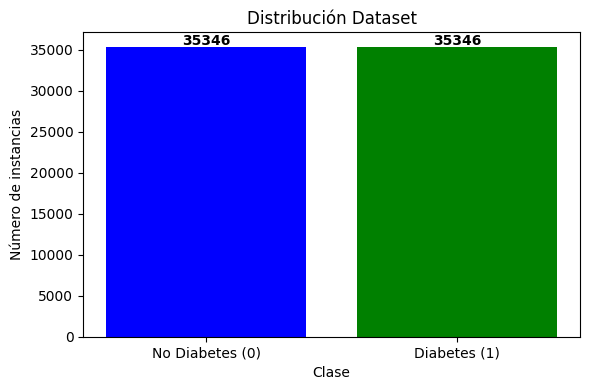

In [3]:
import matplotlib.pyplot as plt

# Contar cuántos hay de cada clase
conteo = df_iris['Diabetes_binary'].value_counts()

# Graficar
plt.figure(figsize=(6, 4))
plt.bar(['No Diabetes (0)', 'Diabetes (1)'], conteo.values, color=['blue', 'green'])
plt.title('Distribución Dataset')
plt.xlabel('Clase')
plt.ylabel('Número de instancias')
plt.tight_layout()

# Agregar los números encima de cada barra
for i, valor in enumerate(conteo.values):
    plt.text(i, valor + 200, str(valor), ha='center', fontweight='bold')

plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import numpy as np

# Separate features (X) and target (y) - X is already DataFrame, y is Series of strings
X = df_iris[['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
             'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
             'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
             'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']]
y_raw = df_iris['Diabetes_binary']

# Encode the target variable (species) to numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
target_names = le.classes_.tolist() # Store target names for later use

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-hot encode the target variable
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

print(f"Feature names: {X.columns.tolist()}")
print(f"Target names: {target_names}")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of y_train_encoded: {y_train_encoded.shape}")
print(f"First 5 one-hot encoded targets in training set:\n{y_train_encoded[:5]}")

Feature names: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Target names: [0.0, 1.0]
Shape of X_train_scaled: (56553, 21)
Shape of y_train_encoded: (56553, 2)
First 5 one-hot encoded targets in training set:
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


Red neuronal convolutiva:

In [5]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
#Entrance X
model.add(layers.Input(shape=(21,)))
model.add(layers.Dense(256,activation='relu'))
#model.add(layers.Dense(128,activation='relu'))

#Sigmoid as activation function for classification
model.add(layers.Dense(1,activation='sigmoid'))

model.summary()

model.compile(loss='binary_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=['acc','precision','recall'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - acc: 0.6950 - loss: 0.5930 - precision: 0.7105 - recall: 0.6581 - val_acc: 0.7408 - val_loss: 0.5324 - val_precision: 0.7372 - val_recall: 0.7502
Epoch 2/10
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - acc: 0.7431 - loss: 0.5223 - precision: 0.7375 - recall: 0.7549 - val_acc: 0.7475 - val_loss: 0.5145 - val_precision: 0.7398 - val_recall: 0.7653
Epoch 3/10
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7464 - loss: 0.5131 - precision: 0.7378 - recall: 0.7643 - val_acc: 0.7519 - val_loss: 0.5099 - val_precision: 0.7397 - val_recall: 0.7791
Epoch 4/10
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7489 - loss: 0.5098 - precision: 0.7373 - recall: 0.7731 - val_acc: 0.7530 - val_loss: 0.5082 - val_precision: 0.7388 - val_recall: 0.7844
Epoch 5/10
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.7501 - loss: 0.5080 - precision: 0.7367 - recall: 0.7783 - val_acc: 0.7521 - val_loss: 0.5072 - val_precision: 0.7380 - val_recal

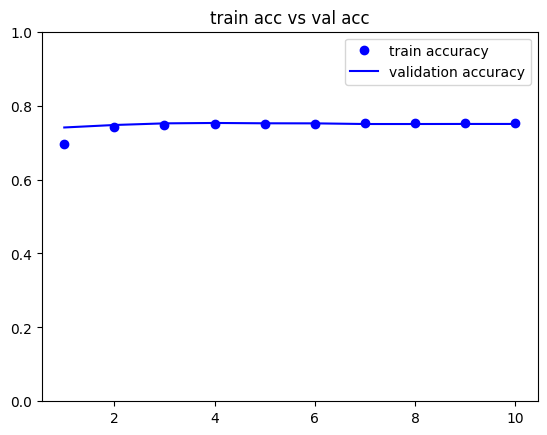

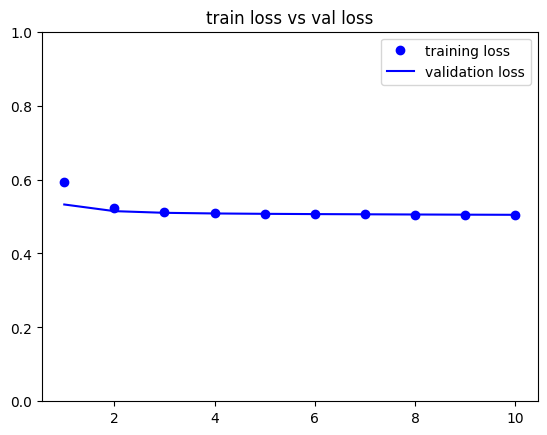

In [6]:
history = model.fit(X_train_scaled, y_train,
				epochs = 10,
				validation_split =.10,
        batch_size=32)


acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

# Accuracy
plt.plot(epochs, acc, 'bo', label='train accuracy')
plt.plot(epochs, val_acc, 'b', label='validation accuracy')
plt.title('train acc vs val acc')
plt.ylim(0, 1)
plt.legend()

plt.figure()

# Loss Graphic
plt.plot(epochs, loss, 'bo', label='training loss')
plt.plot(epochs, val_loss, 'b', label='validation loss')
plt.title('train loss vs val loss')
plt.ylim(0, 1)
plt.legend()

plt.show()

# **Confusion Matrix**

442/442 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[5045 2025]
 [1524 5545]]


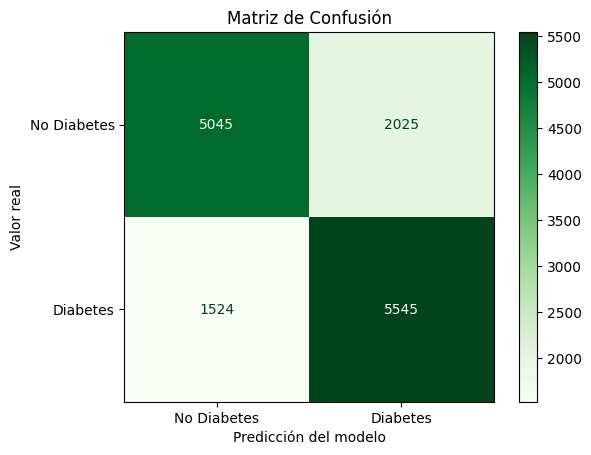

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = y_test

# Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Graph
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Greens')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()